In [167]:
# import all libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [168]:
# import data 
df = pd.read_csv(r'D:\Power BI project\Dataset.csv')

# Data Preprocessing

In [169]:
# Checked the basic information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1470 non-null   int64
 1   Attrition                1470 non-null   int64
 2   BusinessTravel           1470 non-null   str  
 3   DailyRate                1470 non-null   int64
 4   Department               1470 non-null   str  
 5   DistanceFromHome         1470 non-null   int64
 6   Education                1470 non-null   int64
 7   EducationField           1470 non-null   str  
 8   EmployeeCount            1470 non-null   int64
 9   EmployeeNumber           1470 non-null   int64
 10  EnvironmentSatisfaction  1470 non-null   int64
 11  Gender                   1470 non-null   str  
 12  JobLevel                 1470 non-null   int64
 13  JobRole                  1470 non-null   str  
 14  JobSatisfaction          1470 non-null   int64
 15  MaritalStatus  

In [170]:
# checking null values
df.isnull().sum()

Age                        0
Attrition                  0
BusinessTravel             0
DailyRate                  0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeNumber             0
EnvironmentSatisfaction    0
Gender                     0
JobLevel                   0
JobRole                    0
JobSatisfaction            0
MaritalStatus              0
MonthlyIncome              0
PerformanceRating          0
TotalWorkingYears          0
TrainingTimesLastYear      0
WorkLifeBalance            0
YearsAtCompany             0
dtype: int64

In [171]:
# checking columns
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'JobLevel',
       'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'PerformanceRating', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany'],
      dtype='str')

In [172]:
# Dropping these columns helps the model focus on relevant features only
df.drop(['EmployeeCount','EmployeeNumber','DailyRate'],axis=1,inplace=True)

In [173]:
# checked after dropping columns 
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'PerformanceRating', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='str')

In [174]:
# Some columns had text values like JobRole, Department, OverTime etc.
# Machine learning models only understand numbers, not text
# So used LabelEncoder to convert all text columns into numeric format

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.select_dtypes(include='object').columns:
    df[i] = le.fit_transform(df[i])

In [175]:
# divide data into feature and target
feature = df.drop('Attrition',axis=1)
target = df['Attrition'] 

In [176]:
feature

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany
0,51,2,1,6,3,1,1,1,5,5,3,2,19537,3,23,5,3,20
1,52,2,1,1,4,1,3,1,5,3,3,1,19999,3,34,5,3,33
2,42,2,1,4,2,5,3,1,5,3,4,1,19232,3,22,3,3,22
3,47,2,1,2,4,3,1,0,4,5,3,1,17169,3,26,2,4,20
4,46,2,2,3,3,5,1,0,4,7,1,0,13225,3,25,5,3,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,25,2,0,2,3,0,3,0,1,1,2,1,2187,3,6,3,3,2
1466,40,2,1,1,4,1,1,1,1,2,4,1,2406,3,8,3,2,1
1467,39,0,1,9,3,1,4,1,5,3,4,2,19431,3,21,3,2,6
1468,23,1,2,9,3,2,4,1,1,8,1,1,1790,3,1,3,2,1


In [177]:
target

0       0
1       0
2       0
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    1
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [178]:
# Split the data into 80% training and 20% testing
# random_state=42 ensures we get the same split every time we run
# model will train on xtrain and will be tested on unseen xtest data

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(feature, target, test_size=0.2, random_state=42)

In [179]:
# Checked the distribution of our target column Attrition
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [180]:
# pip install imbalanced-learn

In [181]:
# After checking value counts, 84% employees had No Attrition and only 16% had Yes
# This imbalance made the model biased towards predicting No every time
# SMOTE creates synthetic samples of the minority class (Attrition=Yes)
# This helps the model learn both classes equally instead of ignoring one

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
xtrain, ytrain = smote.fit_resample(xtrain, ytrain)

In [182]:
# Different columns had very different ranges
# For example Age was 18-60 but MonthlyIncome was 1000-20000
# StandardScaler brings all features to the same scale
# fit only on xtrain, transform on xtest to avoid any data leakage

from sklearn.preprocessing import StandardScaler
st = StandardScaler()
xtrain = st.fit_transform(xtrain)
xtest = st.transform(xtest)

# Model Building

In [183]:
# First tried Random Forest as it is one of the most widely used classification models
# It builds multiple decision trees and combines their results

from sklearn.ensemble import RandomForestClassifier
rfs = RandomForestClassifier(random_state=42)
rfs.fit(xtrain, ytrain)
ypred = rfs.predict(xtest)

In [184]:
# checking the Accuracy Score
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(ytest, ypred))
print(classification_report(ytest, ypred))
print()

print('the recall for Class 1 (Attrition=Yes) came out very low at 0.29'
       ' meaning the model was missing most of the actual attrition cases.'
       ' So we decided to try a different model for better results')

Accuracy: 0.8061224489795918
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       249
           1       0.34      0.29      0.31        45

    accuracy                           0.81       294
   macro avg       0.61      0.59      0.60       294
weighted avg       0.79      0.81      0.80       294


the recall for Class 1 (Attrition=Yes) came out very low at 0.29 meaning the model was missing most of the actual attrition cases. So we decided to try a different model for better results


# Second Attempt

In [185]:
# Gradient Boosting learns from previous mistakes and improves step by step
# First ran it with default settings to see the base performance

from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(xtrain, ytrain)
ypred = gbc.predict(xtest)

In [186]:
# checking the Accuracy Score
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(ytest, ypred))
print(classification_report(ytest, ypred))
print()
print('Result was slightly better than Random Forest but still not satisfying Class 1 recall improved a bit but accuracy dropped to 0.78 So we decided to tune the hyperparameters to get better results')

Accuracy: 0.782312925170068
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       249
           1       0.32      0.38      0.35        45

    accuracy                           0.78       294
   macro avg       0.60      0.62      0.61       294
weighted avg       0.80      0.78      0.79       294


Result was slightly better than Random Forest but still not satisfying Class 1 recall improved a bit but accuracy dropped to 0.78 So we decided to tune the hyperparameters to get better results


In [187]:
# After seeing base results we tuned the hyperparameters manually
# n_estimators=200 so model learns from more trees and captures better patterns
# max_depth=4 kept low to avoid overfitting on training data
# learning_rate=0.05 so model learns slowly and does not make aggressive mistakes

from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=42 , n_estimators=200 , max_depth=4 , learning_rate=0.05)
gbc.fit(xtrain, ytrain)
ypred = gbc.predict(xtest)

In [188]:
# checking the Accuracy Score
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(ytest, ypred))
print(classification_report(ytest, ypred))
print()
print('After tuning accuracy came back to 0.81 and Class 1 results also improved Train and Test accuracy gap was small'
      ' so model is not overfitting Hence finalized this tuned Gradient Boosting as our final model')

Accuracy: 0.8095238095238095
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       249
           1       0.37      0.36      0.36        45

    accuracy                           0.81       294
   macro avg       0.63      0.62      0.63       294
weighted avg       0.81      0.81      0.81       294


After tuning accuracy came back to 0.81 and Class 1 results also improved Train and Test accuracy gap was small so model is not overfitting Hence finalized this tuned Gradient Boosting as our final model


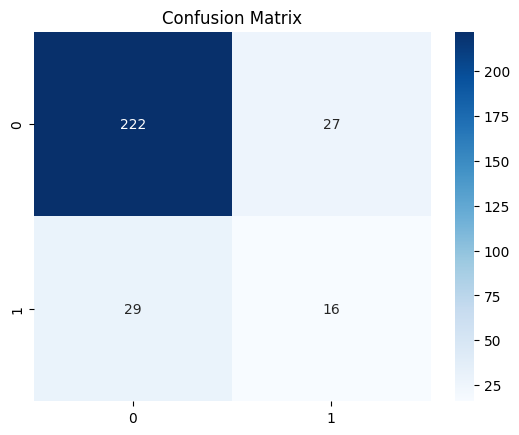

In [189]:
# Confusion Matrix gives a clear picture of how many cases were correctly predicted
# and how many were missed, especially for the Attrition=Yes class
# This is more meaningful than just looking at accuracy alone

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, ypred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Conclusion
>In this project we predicted employee attrition using the HR Attrition dataset which we had already analyzed in Power BI. The goal was to build a machine learning model that can identify which employees are likely to leave the company.
After importing the data we performed basic checks like null values, data types and class distribution. We found that the dataset was highly imbalanced with around 84% employees having No Attrition and only 16% having Yes Attrition which was a major challenge.
To handle this we applied SMOTE on the training data to balance both classes so the model does not get biased towards the majority class.
We first tried Random Forest Classifier with default settings but the recall for Attrition=Yes class was very low at 0.29 which means the model was missing most of the actual attrition cases. So we decided to switch the model.
We then tried Gradient Boosting Classifier first with default parameters which gave slightly better results. After that we tuned the hyperparameters by setting n_estimators=200, max_depth=4 and learning_rate=0.05. This gave us the best results with accuracy of 0.81 and improved recall for the minority class with no overfitting issue.
The Confusion Matrix confirmed that the final model was performing reasonably well on both classes compared to our initial attempts.
Overall this project gave us hands on experience with real world problems like class imbalance, model selection and hyperparameter tuning which are very important aspects of any machine learning project.